In [2]:
!pip install langgraph langchain langchain-google-genai google-generativeai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.4 MB/s eta 0:00:00


In [3]:
import os
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

# Set your Gemini API Key
os.environ["GOOGLE_API_KEY"] = "API KEY"

# Initialize Gemini 2.5 Flash
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)

In [4]:
class TelecomState(TypedDict):
    # Input fields
    customer_id: str
    aadhaar_number: str
    pan_number: str
    customer_location: str
    previous_sim_requests: int

    # Intermediate outputs
    kyc_status: str           # VERIFIED | INVALID_DOCUMENT | PENDING_VERIFICATION
    fraud_risk: str           # LOW_RISK | MEDIUM_RISK | HIGH_RISK
    fraud_reasoning: str

    # Final output
    activation_decision: str  # SIM Activated | Manual Review | Reject Application
    final_message: str

print("TelecomState schema defined.")

TelecomState schema defined.


In [5]:
@tool
def kyc_verification_tool(aadhaar_number: str, pan_number: str) -> str:
    """
    Validates customer KYC documents.
    Checks Aadhaar and PAN number format and returns verification status.
    Returns: VERIFIED, INVALID_DOCUMENT, or PENDING_VERIFICATION
    """
    aadhaar_valid = len(aadhaar_number) == 12 and aadhaar_number.isdigit()

    pan_valid = (
        len(pan_number) == 10
        and pan_number[:5].isalpha()
        and pan_number[5:9].isdigit()
        and pan_number[9].isalpha()
    )

    if aadhaar_valid and pan_valid:
        return "VERIFIED"
    elif not aadhaar_valid and not pan_valid:
        return "INVALID_DOCUMENT"
    else:
        return "PENDING_VERIFICATION"

print("KYC Verification Tool defined.")

KYC Verification Tool defined.


In [6]:
def kyc_verification_node(state: TelecomState) -> TelecomState:
    """
    Node 1: Invokes the KYC verification tool and updates the workflow state.
    """
    print("[Node 1] Running KYC Verification...")

    result = kyc_verification_tool.invoke({
        "aadhaar_number": state["aadhaar_number"],
        "pan_number": state["pan_number"]
    })

    print(f"KYC Status: {result}")
    return {**state, "kyc_status": result}


In [8]:
def fraud_detection_node(state: TelecomState) -> TelecomState:
    """
    Node 2: Uses Gemini to analyze fraud risk based on KYC status,
    customer location, and previous SIM request history.
    """
    print("[Node 2] Running Gemini Fraud Detection Analysis...")

    prompt = f"""
You are a fraud detection system for a telecom company.

Analyze the following customer data and classify the fraud risk level.

Customer ID: {state['customer_id']}
KYC Status: {state['kyc_status']}
Customer Location: {state['customer_location']}
Number of Previous SIM Requests: {state['previous_sim_requests']}

Instructions:
1. Classify the fraud risk as exactly one of: LOW_RISK, MEDIUM_RISK, HIGH_RISK
2. Provide a brief reasoning in 2 to 3 sentences.

Respond strictly in the following format:
RISK_LEVEL: <LOW_RISK|MEDIUM_RISK|HIGH_RISK>
REASONING: <your reasoning here>
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    response_text = response.content.strip()

    print(f"Gemini Response:\n{response_text}")

    risk_level = "MEDIUM_RISK"
    reasoning = "Reasoning not parsed."

    for line in response_text.split("\n"):
        if line.startswith("RISK_LEVEL:"):
            risk_level = line.replace("RISK_LEVEL:", "").strip()
        elif line.startswith("REASONING:"):
            reasoning = line.replace("REASONING:", "").strip()

    return {**state, "fraud_risk": risk_level, "fraud_reasoning": reasoning}

In [9]:
def activation_decision_node(state: TelecomState) -> TelecomState:
    """
    Node 3: Determines the final SIM activation outcome based on the fraud risk level.
    LOW_RISK     -> SIM Activated
    MEDIUM_RISK  -> Manual Review
    HIGH_RISK    -> Reject Application
    """
    print("[Node 3] Making Final Activation Decision...")

    fraud_risk = state["fraud_risk"]

    if fraud_risk == "LOW_RISK":
        decision = "SIM Activated"
        message = (
            f"Customer {state['customer_id']}: SIM has been successfully activated."
        )
    elif fraud_risk == "MEDIUM_RISK":
        decision = "Manual Review"
        message = (
            f"Customer {state['customer_id']}: Application has been flagged for manual review."
        )
    else:
        decision = "Reject Application"
        message = (
            f"Customer {state['customer_id']}: Application rejected due to high fraud risk."
        )

    print(f"Decision: {decision}")
    return {**state, "activation_decision": decision, "final_message": message}

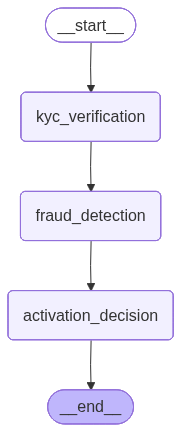

In [10]:
telecom_workflow = StateGraph(TelecomState)

telecom_workflow.add_node("kyc_verification", kyc_verification_node)
telecom_workflow.add_node("fraud_detection", fraud_detection_node)
telecom_workflow.add_node("activation_decision", activation_decision_node)

telecom_workflow.set_entry_point("kyc_verification")
telecom_workflow.add_edge("kyc_verification", "fraud_detection")
telecom_workflow.add_edge("fraud_detection", "activation_decision")
telecom_workflow.add_edge("activation_decision", END)

telecom_app = telecom_workflow.compile()
telecom_app


In [11]:
print("USE CASE 1: Telecom SIM Activation Workflow")
print("-" * 50)

customer_low_risk = {
    "customer_id": "CUST-001",
    "aadhaar_number": "123456789012",
    "pan_number": "ABCDE1234F",
    "customer_location": "Mumbai, Maharashtra",
    "previous_sim_requests": 1,
    "kyc_status": "",
    "fraud_risk": "",
    "fraud_reasoning": "",
    "activation_decision": "",
    "final_message": ""
}

print("Test Case 1: Valid Customer with Low SIM Request History")
result_1 = telecom_app.invoke(customer_low_risk)

print("\nFINAL REPORT - Customer 1")
print(f"KYC Status         : {result_1['kyc_status']}")
print(f"Fraud Risk         : {result_1['fraud_risk']}")
print(f"Fraud Reasoning    : {result_1['fraud_reasoning']}")
print(f"Activation Decision: {result_1['activation_decision']}")
print(f"Final Message      : {result_1['final_message']}")

USE CASE 1: Telecom SIM Activation Workflow
--------------------------------------------------
Test Case 1: Valid Customer with Low SIM Request History
[Node 1] Running KYC Verification...
KYC Status: VERIFIED
[Node 2] Running Gemini Fraud Detection Analysis...
Gemini Response:
RISK_LEVEL: LOW_RISK
REASONING: The customer's KYC status is verified, which significantly reduces the risk of identity fraud. Furthermore, having only one previous SIM request indicates normal customer behavior and does not suggest any suspicious activity like bulk SIM acquisition or SIM swap attempts.
[Node 3] Making Final Activation Decision...
Decision: SIM Activated

FINAL REPORT - Customer 1
KYC Status         : VERIFIED
Fraud Risk         : LOW_RISK
Fraud Reasoning    : The customer's KYC status is verified, which significantly reduces the risk of identity fraud. Furthermore, having only one previous SIM request indicates normal customer behavior and does not suggest any suspicious activity like bulk SIM 

In [12]:
customer_high_risk = {
    "customer_id": "CUST-002",
    "aadhaar_number": "INVALIDNUM",
    "pan_number": "WRONGPAN99",
    "customer_location": "Unknown Location",
    "previous_sim_requests": 8,
    "kyc_status": "",
    "fraud_risk": "",
    "fraud_reasoning": "",
    "activation_decision": "",
    "final_message": ""
}

print("Test Case 2: Invalid Documents with High SIM Request History")
result_2 = telecom_app.invoke(customer_high_risk)

print("\nFINAL REPORT - Customer 2")
print(f"KYC Status         : {result_2['kyc_status']}")
print(f"Fraud Risk         : {result_2['fraud_risk']}")
print(f"Fraud Reasoning    : {result_2['fraud_reasoning']}")
print(f"Activation Decision: {result_2['activation_decision']}")
print(f"Final Message      : {result_2['final_message']}")

Test Case 2: Invalid Documents with High SIM Request History
[Node 1] Running KYC Verification...
KYC Status: INVALID_DOCUMENT
[Node 2] Running Gemini Fraud Detection Analysis...
Gemini Response:
RISK_LEVEL: HIGH_RISK
REASONING: The "INVALID_DOCUMENT" KYC status indicates the customer's identity cannot be verified, which is a critical red flag. This is further compounded by an "Unknown Location" and a high number of previous SIM requests (8). These combined factors strongly suggest a high potential for fraudulent activity.
[Node 3] Making Final Activation Decision...
Decision: Reject Application

FINAL REPORT - Customer 2
KYC Status         : INVALID_DOCUMENT
Fraud Risk         : HIGH_RISK
Fraud Reasoning    : The "INVALID_DOCUMENT" KYC status indicates the customer's identity cannot be verified, which is a critical red flag. This is further compounded by an "Unknown Location" and a high number of previous SIM requests (8). These combined factors strongly suggest a high potential for f

#### Scenario 2

In [13]:
class HealthcareState(TypedDict):
    # Input fields
    patient_id: str
    patient_name: str
    age: int
    symptoms: list
    fever_celsius: float
    oxygen_level: int          # SpO2 percentage
    heart_rate: int            # Beats per minute
    symptom_duration_hours: int
    existing_conditions: list

    # Intermediate outputs
    severity_level: str        # STABLE | MODERATE | CRITICAL
    priority_level: str        # EMERGENCY | PRIORITY_CONSULTATION | REGULAR_CONSULTATION
    priority_reasoning: str

    # Final output
    consultation_type: str     # ICU/ER | Specialist Doctor | General Physician
    final_message: str

In [14]:
@tool
def symptom_severity_tool(
    fever_celsius: float,
    oxygen_level: int,
    heart_rate: int,
    symptom_duration_hours: int
) -> str:
    """
    Analyzes patient vitals and classifies symptom severity.
    Returns: CRITICAL, MODERATE, or STABLE
    """
    critical_flags = 0
    moderate_flags = 0

    # Fever assessment
    if fever_celsius >= 39.5:
        critical_flags += 1
    elif fever_celsius >= 38.0:
        moderate_flags += 1

    # Oxygen saturation assessment
    if oxygen_level < 90:
        critical_flags += 2
    elif oxygen_level < 95:
        moderate_flags += 1

    # Heart rate assessment
    if heart_rate > 130 or heart_rate < 45:
        critical_flags += 1
    elif heart_rate > 100 or heart_rate < 60:
        moderate_flags += 1

    # Symptom duration assessment
    if symptom_duration_hours > 168:
        critical_flags += 1
    elif symptom_duration_hours > 72:
        moderate_flags += 1

    if critical_flags >= 2:
        return "CRITICAL"
    elif critical_flags == 1 or moderate_flags >= 2:
        return "MODERATE"
    else:
        return "STABLE"

In [15]:
def symptom_severity_node(state: HealthcareState) -> HealthcareState:
    """
    Node 1: Invokes the symptom severity tool and updates the workflow state.
    """
    print("[Node 1] Running Symptom Severity Analysis...")

    result = symptom_severity_tool.invoke({
        "fever_celsius": state["fever_celsius"],
        "oxygen_level": state["oxygen_level"],
        "heart_rate": state["heart_rate"],
        "symptom_duration_hours": state["symptom_duration_hours"]
    })

    print(f"Severity Level: {result}")
    return {**state, "severity_level": result}

print("Node 1 - Symptom Severity defined.")

Node 1 - Symptom Severity defined.


In [16]:
def medical_prioritization_node(state: HealthcareState) -> HealthcareState:
    """
    Node 2: Uses Gemini to evaluate consultation priority based on
    severity level, patient age, and existing medical conditions.
    """
    print("[Node 2] Running Gemini Medical Prioritization...")

    existing_conditions_str = (
        ", ".join(state["existing_conditions"])
        if state["existing_conditions"]
        else "None"
    )
    symptoms_str = (
        ", ".join(state["symptoms"])
        if state["symptoms"]
        else "Not specified"
    )

    prompt = f"""
You are a hospital triage AI system assisting medical staff in prioritizing patients.

Evaluate the following patient data and determine the appropriate consultation priority.

Patient ID: {state['patient_id']}
Age: {state['age']} years
Reported Symptoms: {symptoms_str}
Vital Signs Severity: {state['severity_level']}
Fever: {state['fever_celsius']} degrees Celsius
Oxygen Saturation (SpO2): {state['oxygen_level']}%
Heart Rate: {state['heart_rate']} BPM
Symptom Duration: {state['symptom_duration_hours']} hours
Existing Medical Conditions: {existing_conditions_str}

Instructions:
1. Classify the consultation priority as exactly one of: EMERGENCY, PRIORITY_CONSULTATION, REGULAR_CONSULTATION
2. Provide clinical reasoning in 2 to 3 sentences.

Respond strictly in the following format:
PRIORITY: <EMERGENCY|PRIORITY_CONSULTATION|REGULAR_CONSULTATION>
REASONING: <your clinical reasoning here>
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    response_text = response.content.strip()

    # print(f"Gemini Response:\n{response_text}")

    priority = "PRIORITY_CONSULTATION"
    reasoning = "Reasoning not parsed."

    for line in response_text.split("\n"):
        if line.startswith("PRIORITY:"):
            priority = line.replace("PRIORITY:", "").strip()
        elif line.startswith("REASONING:"):
            reasoning = line.replace("REASONING:", "").strip()

    return {**state, "priority_level": priority, "priority_reasoning": reasoning}

print("Node 2 - Medical Prioritization defined.")

Node 2 - Medical Prioritization defined.


In [17]:
def consultation_assignment_node(state: HealthcareState) -> HealthcareState:
    """
    Node 3: Assigns the final consultation type based on priority level.
    EMERGENCY               -> ICU/ER
    PRIORITY_CONSULTATION   -> Specialist Doctor
    REGULAR_CONSULTATION    -> General Physician
    """
    print("[Node 3] Assigning Final Consultation Type...")

    priority = state["priority_level"]

    if priority == "EMERGENCY":
        consultation = "ICU/ER"
        message = (
            f"Patient {state['patient_name']} (ID: {state['patient_id']}): "
            f"Immediate transfer to ICU/ER required."
        )
    elif priority == "PRIORITY_CONSULTATION":
        consultation = "Specialist Doctor"
        message = (
            f"Patient {state['patient_name']} (ID: {state['patient_id']}): "
            f"Priority appointment with Specialist Doctor within 2 hours."
        )
    else:
        consultation = "General Physician"
        message = (
            f"Patient {state['patient_name']} (ID: {state['patient_id']}): "
            f"Scheduled for General Physician consultation."
        )

    print(f"Consultation Type: {consultation}")
    return {**state, "consultation_type": consultation, "final_message": message}

print("Node 3 - Consultation Assignment defined.")

Node 3 - Consultation Assignment defined.


Healthcare LangGraph workflow compiled successfully.


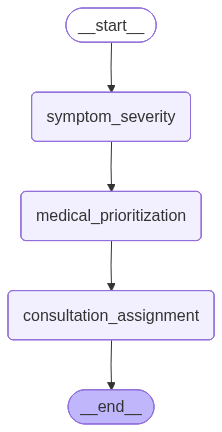

In [18]:
healthcare_workflow = StateGraph(HealthcareState)

healthcare_workflow.add_node("symptom_severity", symptom_severity_node)
healthcare_workflow.add_node("medical_prioritization", medical_prioritization_node)
healthcare_workflow.add_node("consultation_assignment", consultation_assignment_node)

healthcare_workflow.set_entry_point("symptom_severity")
healthcare_workflow.add_edge("symptom_severity", "medical_prioritization")
healthcare_workflow.add_edge("medical_prioritization", "consultation_assignment")
healthcare_workflow.add_edge("consultation_assignment", END)

healthcare_app = healthcare_workflow.compile()

print("Healthcare LangGraph workflow compiled successfully.")
healthcare_app

In [20]:
print("USE CASE 2: Healthcare Appointment Prioritization Workflow")
print("-" * 50)

critical_patient = {
    "patient_id": "PAT-001",
    "patient_name": "John Doe",
    "age": 68,
    "symptoms": ["chest pain", "severe shortness of breath", "dizziness"],
    "fever_celsius": 39.8,
    "oxygen_level": 87,
    "heart_rate": 138,
    "symptom_duration_hours": 6,
    "existing_conditions": ["diabetes", "hypertension", "coronary artery disease"],
    "severity_level": "",
    "priority_level": "",
    "priority_reasoning": "",
    "consultation_type": "",
    "final_message": ""
}

print("Test Case 1: Elderly Patient with Critical Vitals and Multiple Conditions")
result_p1 = healthcare_app.invoke(critical_patient)

print("\nFINAL REPORT - Patient 1")
print(f"Severity Level     : {result_p1['severity_level']}")
print(f"Priority Level     : {result_p1['priority_level']}")
print(f"Clinical Reasoning : {result_p1['priority_reasoning']}")
print(f"Consultation Type  : {result_p1['consultation_type']}")
print(f"Final Message      : {result_p1['final_message']}")

USE CASE 2: Healthcare Appointment Prioritization Workflow
--------------------------------------------------
Test Case 1: Elderly Patient with Critical Vitals and Multiple Conditions
[Node 1] Running Symptom Severity Analysis...
Severity Level: CRITICAL
[Node 2] Running Gemini Medical Prioritization...
[Node 3] Assigning Final Consultation Type...
Consultation Type: ICU/ER

FINAL REPORT - Patient 1
Severity Level     : CRITICAL
Priority Level     : EMERGENCY
Clinical Reasoning : The patient presents with critical vital signs including severe hypoxia (SpO2 87%), significant tachycardia (138 BPM), and high fever, combined with severe shortness of breath and chest pain. These symptoms, especially in an elderly patient with a history of coronary artery disease, indicate an immediate life-threatening condition such as acute respiratory failure, acute coronary syndrome, or severe sepsis requiring urgent medical intervention.
Consultation Type  : ICU/ER
Final Message      : Patient John Doe 

In [21]:
stable_patient = {
    "patient_id": "PAT-002",
    "patient_name": "Smith John",
    "age": 29,
    "symptoms": ["mild cough", "runny nose", "mild sore throat"],
    "fever_celsius": 37.8,
    "oxygen_level": 98,
    "heart_rate": 78,
    "symptom_duration_hours": 48,
    "existing_conditions": [],
    "severity_level": "",
    "priority_level": "",
    "priority_reasoning": "",
    "consultation_type": "",
    "final_message": ""
}

print("Test Case 2: Young Adult with Mild Upper Respiratory Symptoms")
result_p2 = healthcare_app.invoke(stable_patient)

print("\nFINAL REPORT - Patient 2")
print(f"Severity Level     : {result_p2['severity_level']}")
print(f"Priority Level     : {result_p2['priority_level']}")
print(f"Clinical Reasoning : {result_p2['priority_reasoning']}")
print(f"Consultation Type  : {result_p2['consultation_type']}")
print(f"Final Message      : {result_p2['final_message']}")

Test Case 2: Young Adult with Mild Upper Respiratory Symptoms
[Node 1] Running Symptom Severity Analysis...
Severity Level: STABLE
[Node 2] Running Gemini Medical Prioritization...
[Node 3] Assigning Final Consultation Type...
Consultation Type: General Physician

FINAL REPORT - Patient 2
Severity Level     : STABLE
Priority Level     : REGULAR_CONSULTATION
Clinical Reasoning : The patient presents with mild upper respiratory symptoms and stable vital signs, including normal oxygen saturation and heart rate, and a low-grade fever. There are no existing medical conditions or signs of acute distress, indicating a non-urgent condition likely consistent with a common viral illness.
Consultation Type  : General Physician
Final Message      : Patient Smith John (ID: PAT-002): Scheduled for General Physician consultation.


In [22]:
moderate_patient = {
    "patient_id": "PAT-003",
    "patient_name": "Sam Peter",
    "age": 52,
    "symptoms": ["persistent chest tightness", "fatigue", "mild breathlessness"],
    "fever_celsius": 37.2,
    "oxygen_level": 93,
    "heart_rate": 105,
    "symptom_duration_hours": 36,
    "existing_conditions": ["asthma"],
    "severity_level": "",
    "priority_level": "",
    "priority_reasoning": "",
    "consultation_type": "",
    "final_message": ""
}

print("Test Case 3: Middle-Aged Patient with Moderate Vitals and Pre-existing Asthma")
result_p3 = healthcare_app.invoke(moderate_patient)

print("\nFINAL REPORT - Patient 3")
print(f"Severity Level     : {result_p3['severity_level']}")
print(f"Priority Level     : {result_p3['priority_level']}")
print(f"Clinical Reasoning : {result_p3['priority_reasoning']}")
print(f"Consultation Type  : {result_p3['consultation_type']}")
print(f"Final Message      : {result_p3['final_message']}")

Test Case 3: Middle-Aged Patient with Moderate Vitals and Pre-existing Asthma
[Node 1] Running Symptom Severity Analysis...
Severity Level: MODERATE
[Node 2] Running Gemini Medical Prioritization...
[Node 3] Assigning Final Consultation Type...
Consultation Type: Specialist Doctor

FINAL REPORT - Patient 3
Severity Level     : MODERATE
Priority Level     : PRIORITY_CONSULTATION
Clinical Reasoning : The patient presents with persistent chest tightness and breathlessness, coupled with concerning vital signs including mild hypoxemia (SpO2 93%) and tachycardia (HR 105 BPM). Given the history of asthma, these symptoms warrant prompt medical evaluation to rule out a severe asthma exacerbation or potential cardiac involvement.
Consultation Type  : Specialist Doctor
Final Message      : Patient Sam Peter (ID: PAT-003): Priority appointment with Specialist Doctor within 2 hours.
